In [18]:
pip install biopython requests matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [20]:
import requests as requests

In [28]:
RTCB = requests.get("https://alphafold.ebi.ac.uk/files/AF-Q9Y3I0-F1-model_v6.pdb")
with open("RTCB.pdb", "w") as f:    
    f.write(RTCB.text)

In [22]:
from Bio.PDB import *

In [23]:
parser = PDBParser()

In [64]:
structure = PDBParser().get_structure("RTCB", "RTCB.pdb")

bfactor = []
for residue in structure.get_residues():
    if "CA" in residue:
        bfactor.append(residue["CA"].get_bfactor())

print("The lowest iPLDDT value is " + str(min(bfactor)) + " and the highest is " + str(max(bfactor)))

The lowest iPLDDT value is 50.38 and the highest is 98.88


In [72]:
import numpy as np
import pandas as pd
mean_pLDDT = np.average(bfactor)

high = 0
avg = 0
mid = 0
low = 0

for i in bfactor:
    if i > 90:
        high += 1
    elif 70 < i <= 90:
        avg += 1
    elif 50 < i <= 70:
        mid += 1
    elif i < 50:
        low += 1

length = len(bfactor)/100

percents_of_confidence = pd.DataFrame(data=[high/length, avg/length, mid/length, low/length], index= ['>90','70-90','50-70','<50'])
percents_of_confidence

,0
>90,88.316832
70-90,10.495050
50-70,1.188119
<50,0.000000


In [70]:
def disorder(protein):
    '''Input the bfactor file of a protein
    The function will return the longest stretch of suspected disordered residues and its range'''
    longest = -1
    residues = []
    for bfactor in protein:
        while bfactor < 50:
            longest += 1
            residues.append(bfactor.index(longest) + 1)
        
    if longest == -1:
        return "This protein does not have a lot of disorder"
    else:
        return "This protein is disordered from residues " + str(min(residues)) + " - " + str(max(residues)) + " for " + str(longest) + "residues"

disorder(bfactor)

'This protein does not have a lot of disorder'

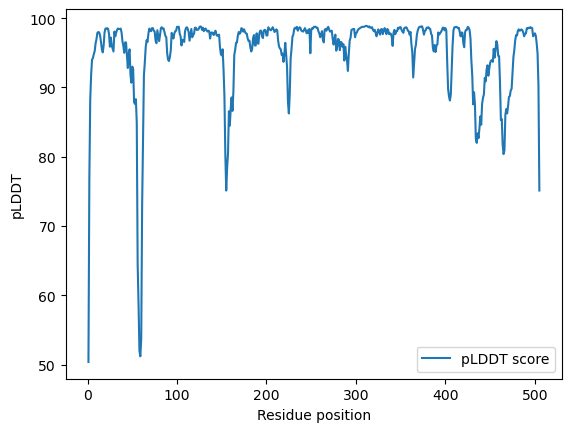

In [103]:
import matplotlib
from matplotlib import pyplot as plt

residueindex = np.arange(1,len(bfactor) + 1)

plt.plot(residueindex, bfactor, label='pLDDT score')
plt.xlabel('Residue position')
plt.ylabel('pLDDT')
plt.legend()
plt.show()

Phase 6: Compare across proteins

Pick 2–3 UniProt IDs with different expected structural character — your public RTCB (Q9Y3I0), plus something well-known and well-folded (e.g. lysozyme, P61626) and something intrinsically disordered (e.g. alpha-synuclein, P37840) for contrast.
Checkpoint: a comparison — either overlaid plots or a small summary table — showing the well-folded protein has way more high-confidence residues than the disordered one. That contrast is the "so what" of the project.

In [58]:
import nglview as nv

view = nv.show_biopython(structure)
view

ModuleNotFoundError: No module named 'nglview'